In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Indian_Kids_Screen_Time.csv")

In [4]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [5]:
df.isnull().sum()[df.isnull().sum()>0]

Health_Impacts    3218
dtype: int64

In [6]:
(df.isnull().sum() / len(df)) * 100


Age                                   0.000000
Gender                                0.000000
Avg_Daily_Screen_Time_hr              0.000000
Primary_Device                        0.000000
Exceeded_Recommended_Limit            0.000000
Educational_to_Recreational_Ratio     0.000000
Health_Impacts                       33.134267
Urban_or_Rural                        0.000000
dtype: float64

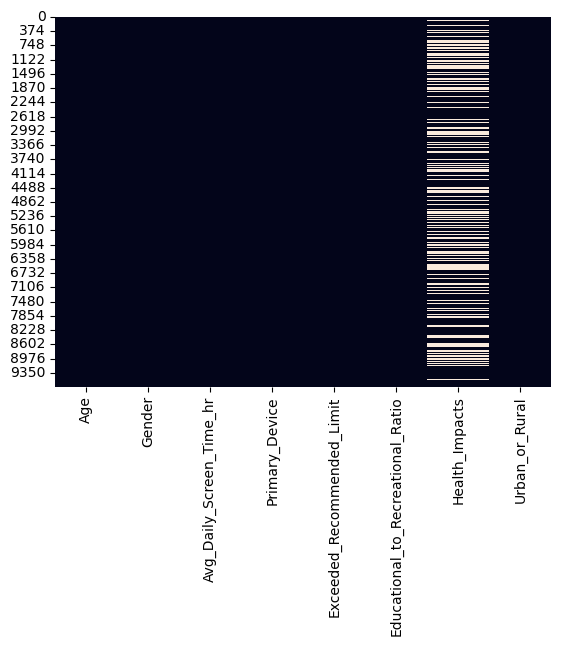

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()


In [8]:
df["Health_Impacts"].fillna("There is no health issue", inplace=True)

In [9]:
print(df["Health_Impacts"].isnull().sum())

0


In [10]:
print(df.shape)        
print(df.columns)      
print(df.info())       


(9712, 8)
Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     9712 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64

In [11]:
print(df.describe())


               Age  Avg_Daily_Screen_Time_hr  \
count  9712.000000               9712.000000   
mean     12.979201                  4.352837   
std       3.162437                  1.718232   
min       8.000000                  0.000000   
25%      10.000000                  3.410000   
50%      13.000000                  4.440000   
75%      16.000000                  5.380000   
max      18.000000                 13.890000   

       Educational_to_Recreational_Ratio  
count                        9712.000000  
mean                            0.427226  
std                             0.073221  
min                             0.300000  
25%                             0.370000  
50%                             0.430000  
75%                             0.480000  
max                             0.600000  


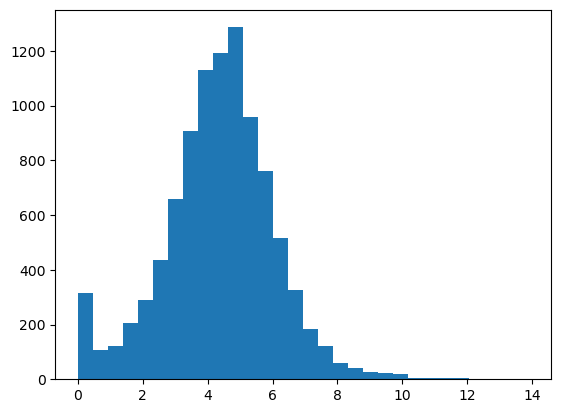

In [18]:
plt.hist(df["Avg_Daily_Screen_Time_hr"], bins=30)
plt.show()


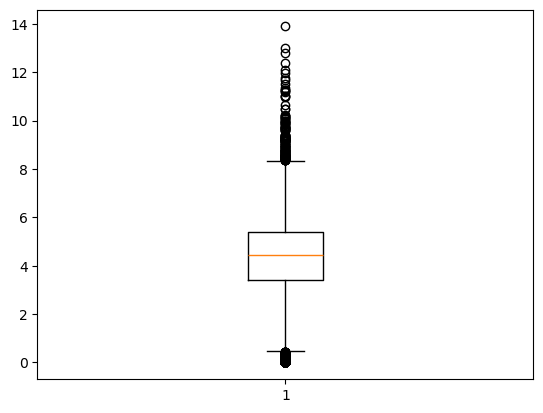

In [19]:
plt.boxplot(df["Avg_Daily_Screen_Time_hr"])
plt.show()


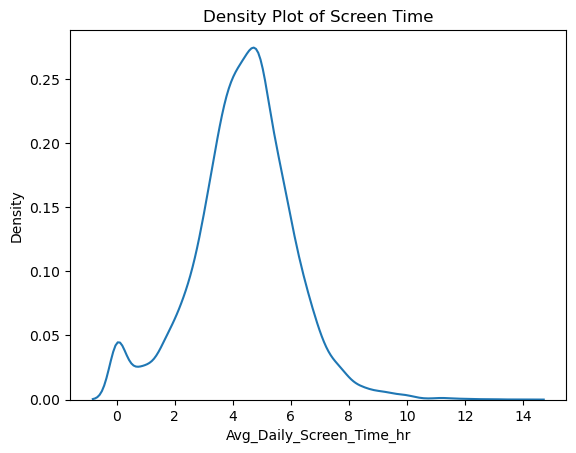

In [29]:
plt.figure()
sns.kdeplot(df["Avg_Daily_Screen_Time_hr"])
plt.title("Density Plot of Screen Time")
plt.show()

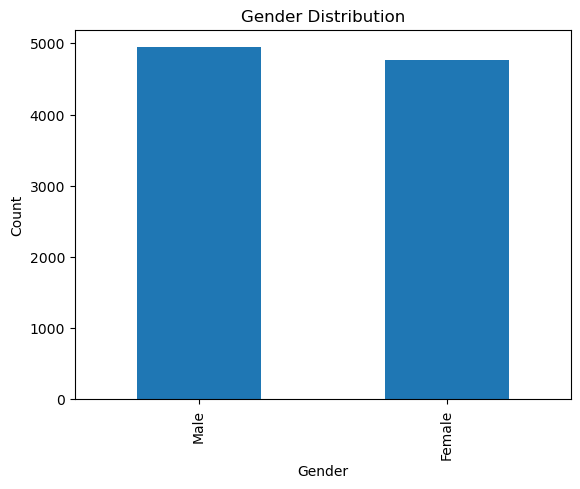

In [30]:
plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

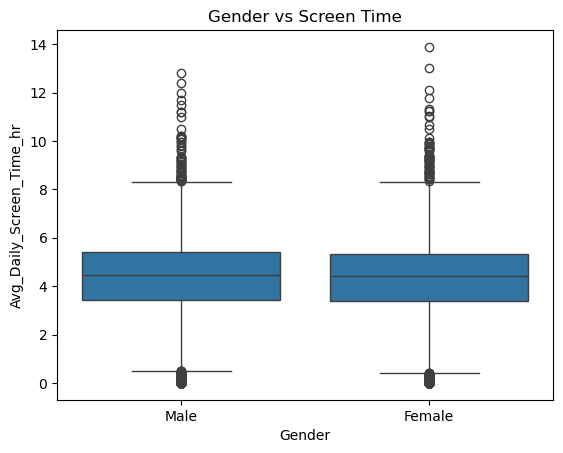

In [31]:
plt.figure()
sns.boxplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Gender vs Screen Time")
plt.show()

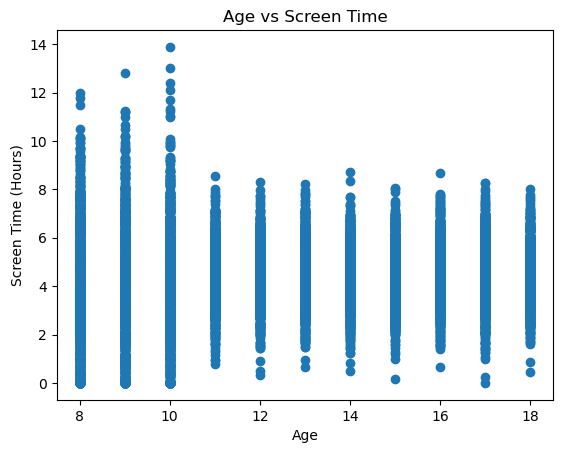

In [24]:
plt.figure()
plt.scatter(df["Age"], df["Avg_Daily_Screen_Time_hr"])
plt.title("Age vs Screen Time")
plt.xlabel("Age")
plt.ylabel("Screen Time (Hours)")
plt.show()


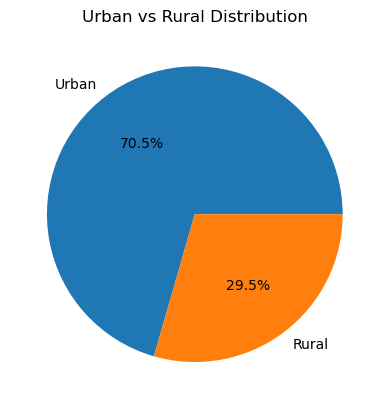

In [25]:
plt.figure()
df["Urban_or_Rural"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Urban vs Rural Distribution")
plt.ylabel("")
plt.show()


<h1>Multivariate Analysis</h1>

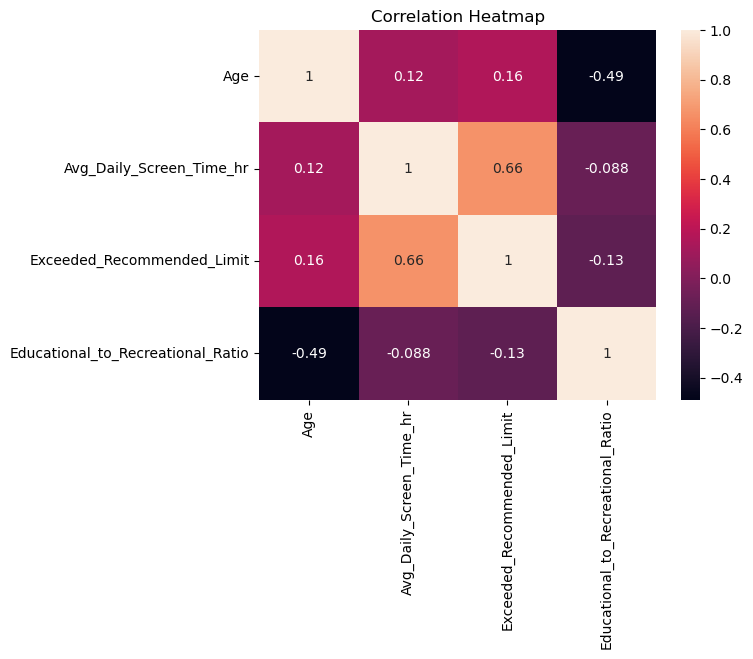

In [32]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
Q1 = df["Avg_Daily_Screen_Time_hr"].quantile(0.25)
Q3 = df["Avg_Daily_Screen_Time_hr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df["Avg_Daily_Screen_Time_hr"] < lower_bound) | 
              (df["Avg_Daily_Screen_Time_hr"] > upper_bound)]

print("Number of Outliers:", len(outliers))


Lower Bound: 0.4550000000000005
Upper Bound: 8.334999999999999
Number of Outliers: 448


In [43]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[7, 10, 13, 16, 18],
    labels=["Children (8-10)", 
            "Early Teens (11-13)", 
            "Mid Teens (14-16)", 
            "Late Teens (17-18)"]
)

df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,14,Mid Teens (14-16)
1,11,Early Teens (11-13)
2,18,Late Teens (17-18)
3,15,Mid Teens (14-16)
4,12,Early Teens (11-13)


In [44]:
df["Age_Group"].value_counts()

Age_Group
Children (8-10)        2674
Early Teens (11-13)    2643
Mid Teens (14-16)      2636
Late Teens (17-18)     1759
Name: count, dtype: int64

In [46]:
df["Age_Group"].unique()

['Mid Teens (14-16)', 'Early Teens (11-13)', 'Late Teens (17-18)', 'Children (8-10)']
Categories (4, object): ['Children (8-10)' < 'Early Teens (11-13)' < 'Mid Teens (14-16)' < 'Late Teens (17-18)']

In [47]:
median_screen_time = df["Avg_Daily_Screen_Time_hr"].median()
print(median_screen_time)

4.44


In [78]:
median_value = df["Avg_Daily_Screen_Time_hr"].median()

df["Day_Type"] = df["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "Weekend" if x > median_value else "Weekday"
)

In [79]:
df["Day_Type"].value_counts()

Day_Type
Weekday    4883
Weekend    4829
Name: count, dtype: int64

In [63]:
df["Recreational_Share"] = 1 - df["Educational_to_Recreational_Ratio"]

In [ ]:
df["Device_Share"] = df["Primary_Device"].map(
    df["Primary_Device"].value_counts(normalize=True)
)

In [85]:
df["Primary_Device"].value_counts(normalize=True)

Primary_Device
Smartphone    0.470346
TV            0.256075
Laptop        0.147549
Tablet        0.126030
Name: proportion, dtype: float64

In [93]:
df["Portable_Device"] = df["Primary_Device"].isin(["Smartphone", "Tablet"]).astype(int)

In [95]:
df["Health_Risk"] = (
    (df["Avg_Daily_Screen_Time_hr"] > 6) &
    (df["Recreational_Share"] > 0.6)
).astype(int)

In [96]:
df.head(5)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group,Recreational_Share,Day_Type,Device_Share_Percent,Portable_Device,Health_Risk
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Mid Teens (14-16),0.58,Weekday,47.03,1,0
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Early Teens (11-13),0.70,Weekend,14.75,0,0
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teens (17-18),0.68,Weekday,25.61,0,0
3,15,Female,1.21,Laptop,False,0.39,There is no health issue,Urban,Mid Teens (14-16),0.61,Weekday,14.75,0,0
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Early Teens (11-13),0.51,Weekend,47.03,1,0


<h1>UNIVARIATE ANALYSIS</h1>

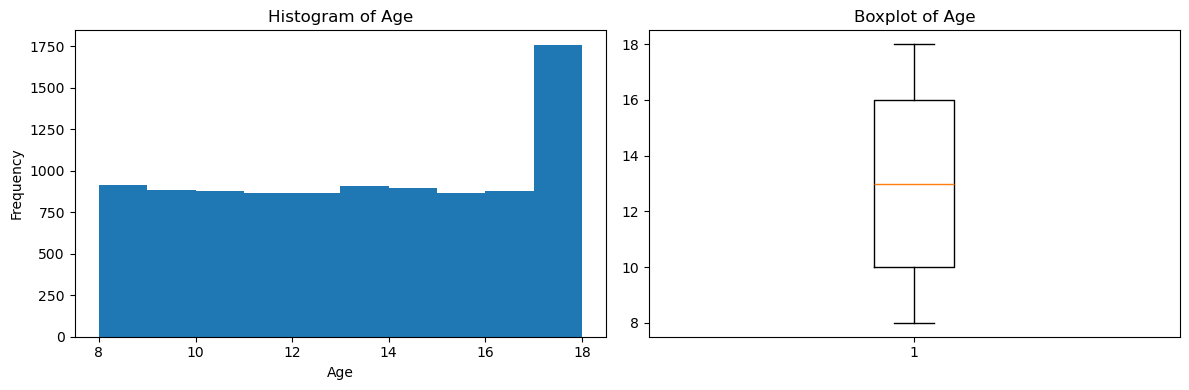

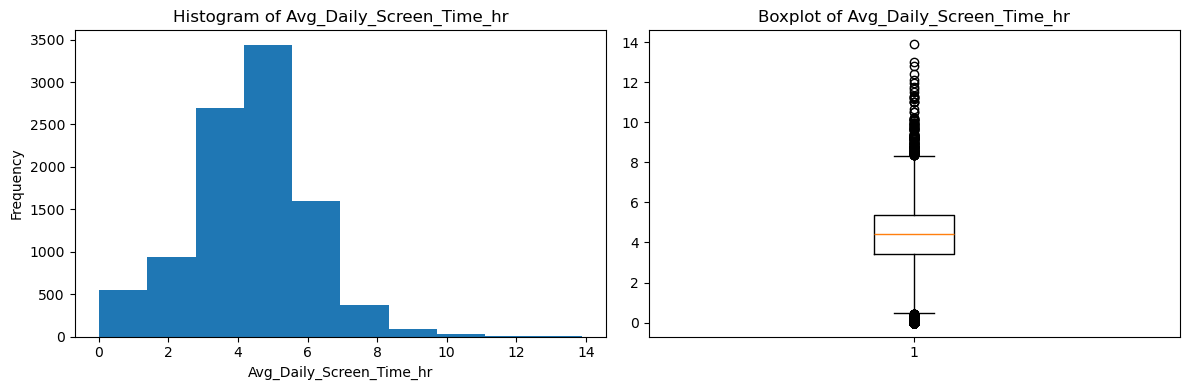

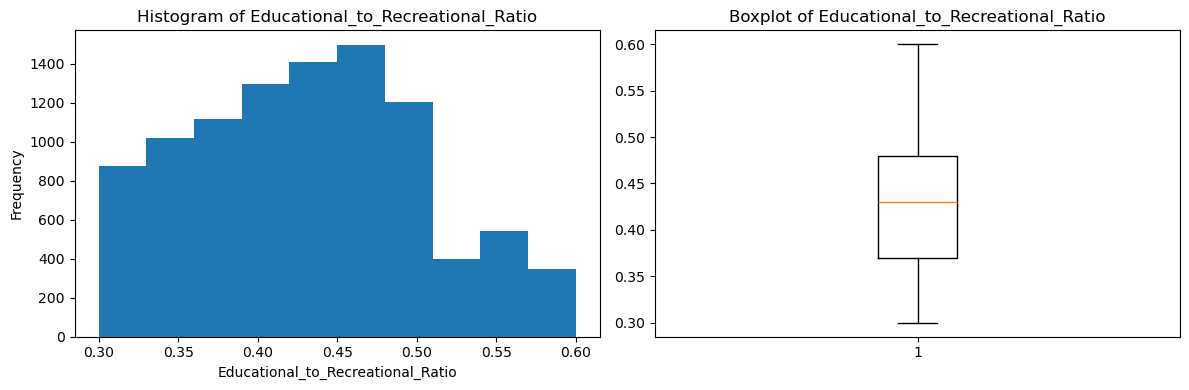

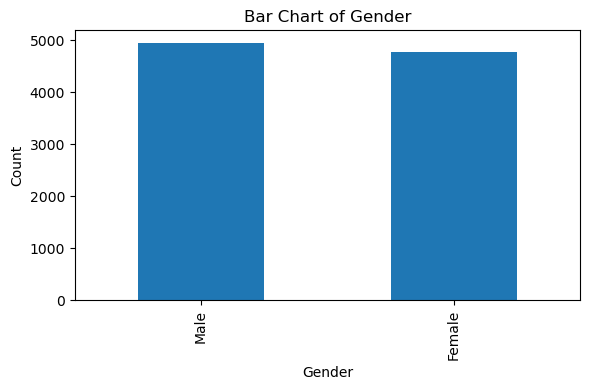

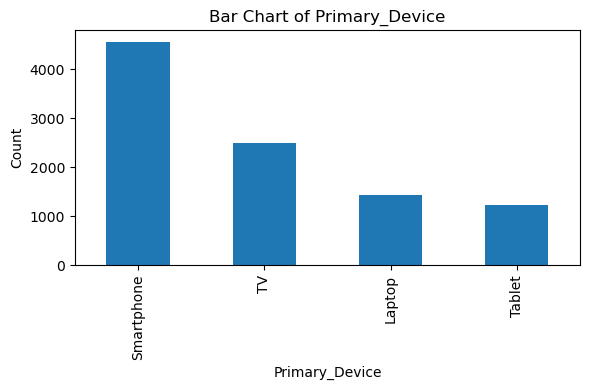

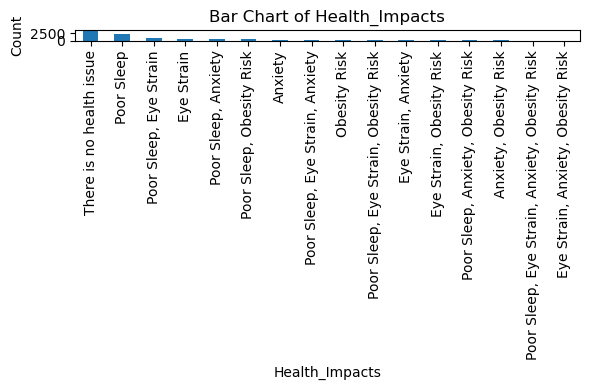

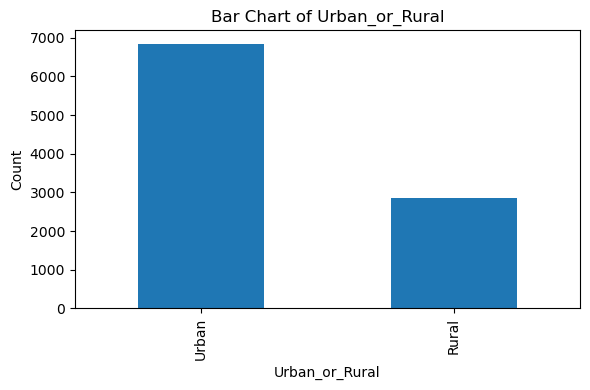

In [26]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    plt.figure(figsize=(12,4))
    
    # Histogram
    plt.subplot(1,2,1)
    plt.hist(df[col], bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    # Boxplot
    plt.subplot(1,2,2)
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()


for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

<h1>BIVARIATE ANALYSIS</h1>

SCATTER PLOTS (Numerical vs Numerical)


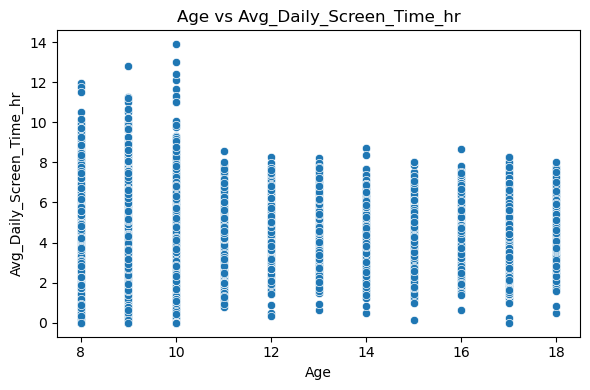

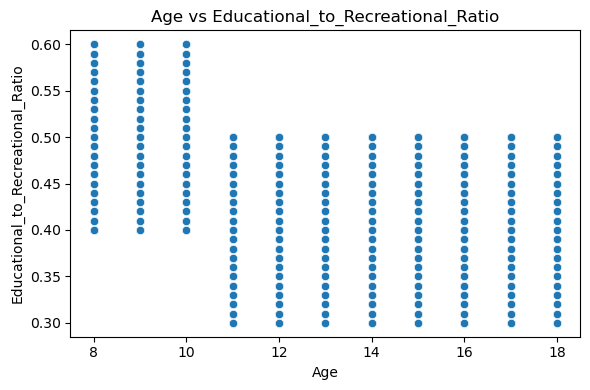

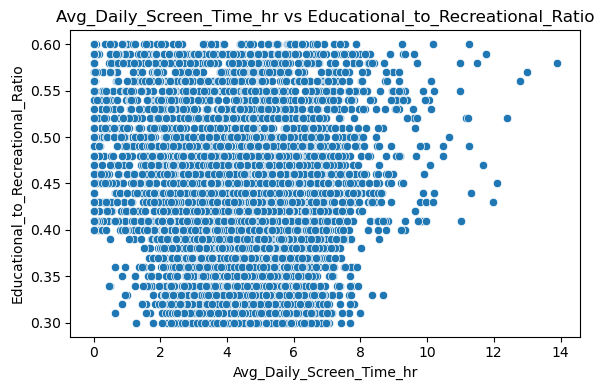

BOX PLOTS (Categorical vs Numerical)


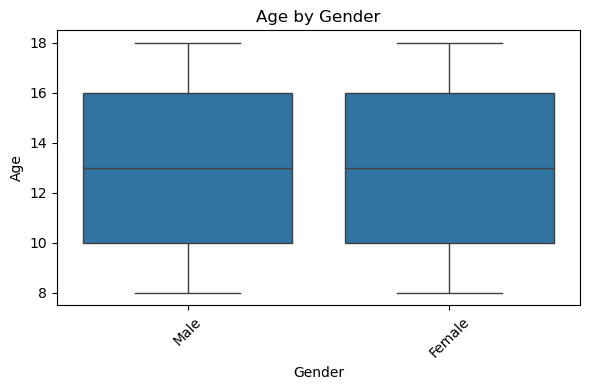

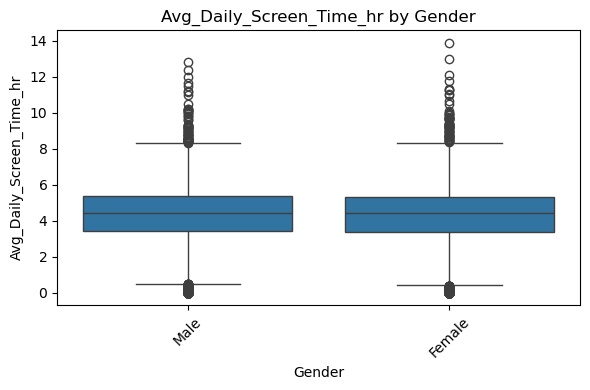

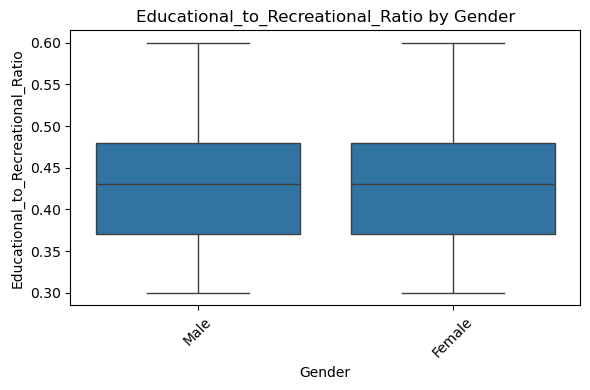

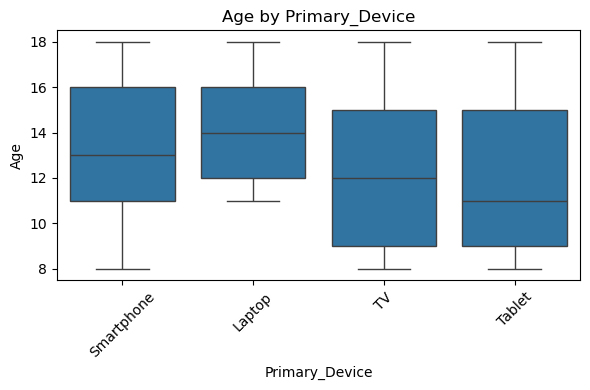

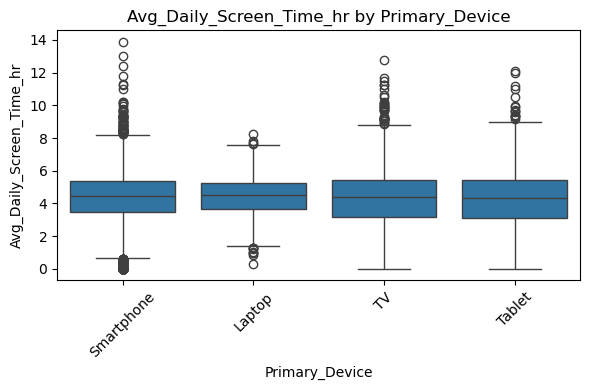

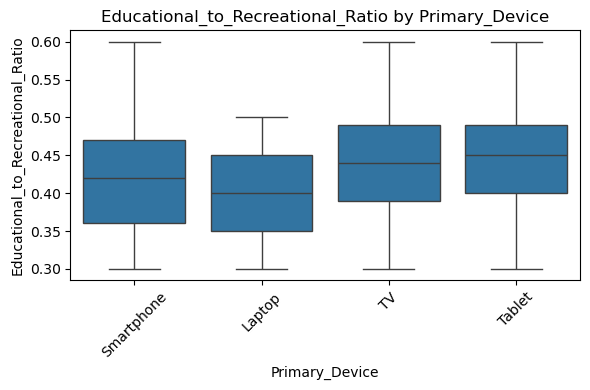

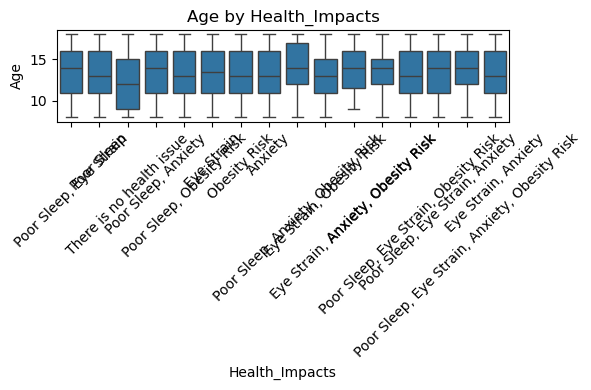

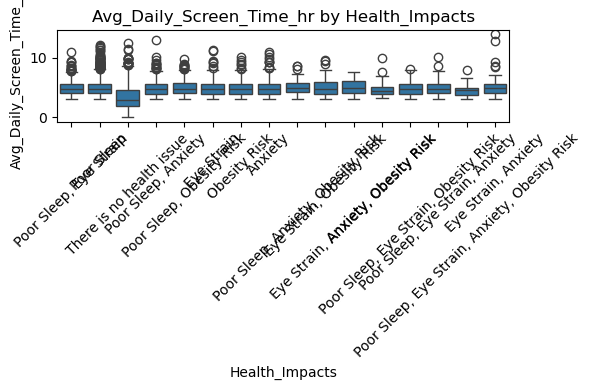

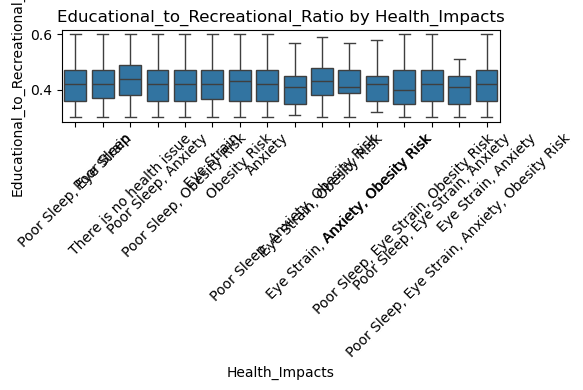

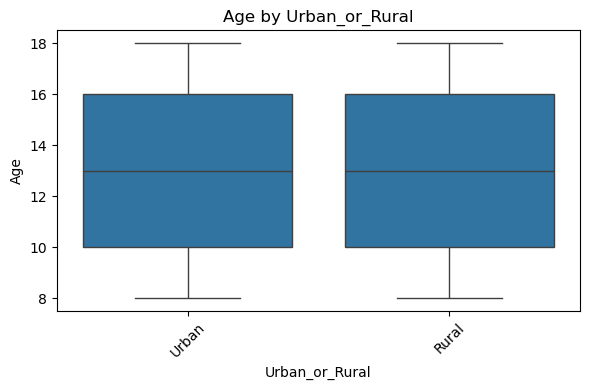

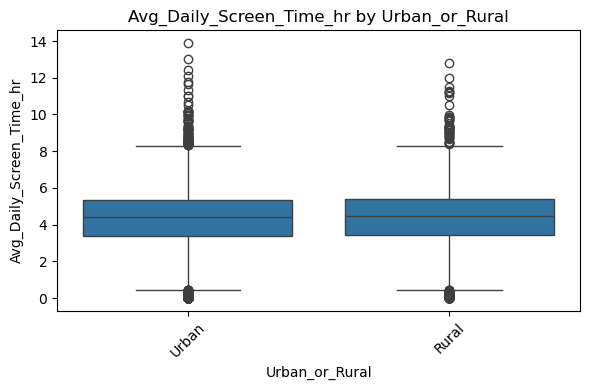

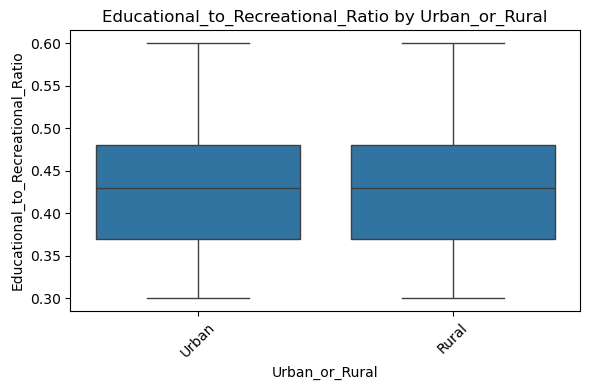

VIOLIN PLOTS (Categorical vs Numerical)


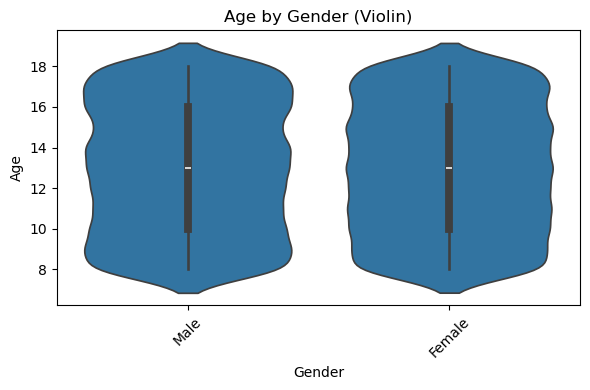

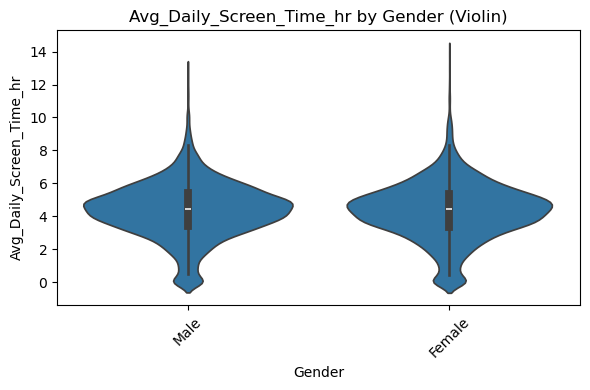

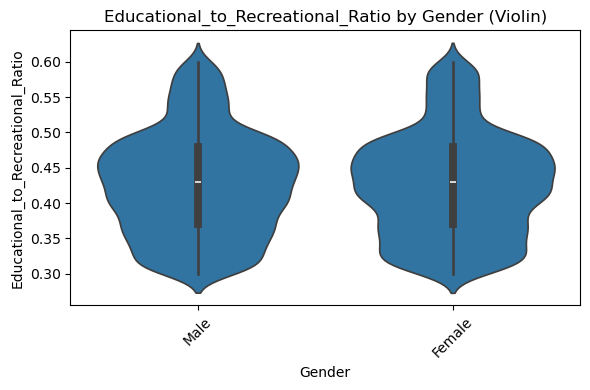

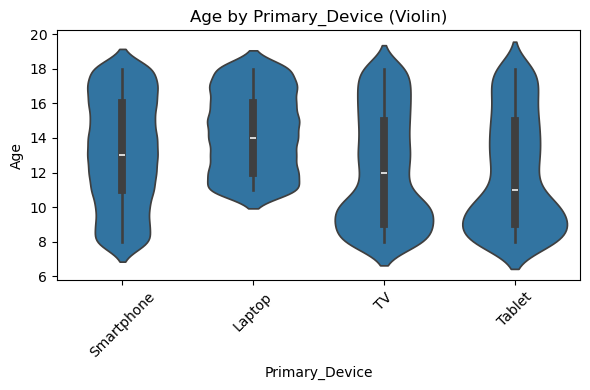

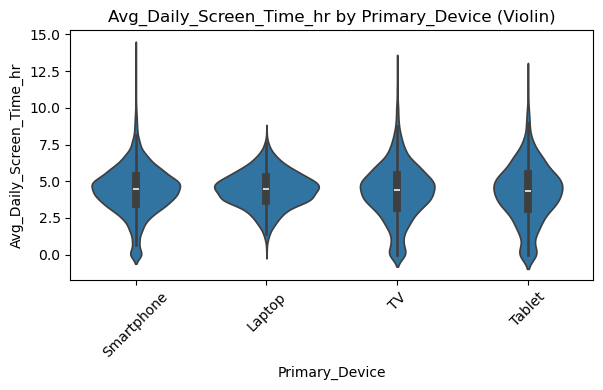

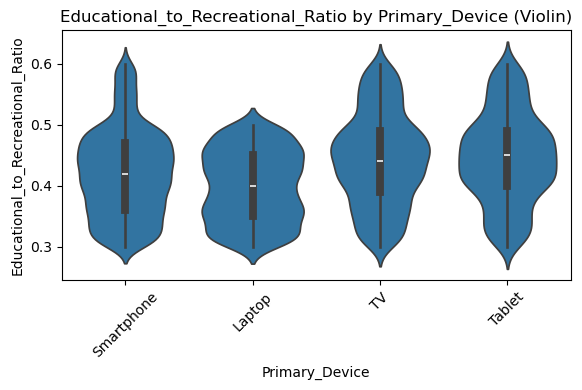

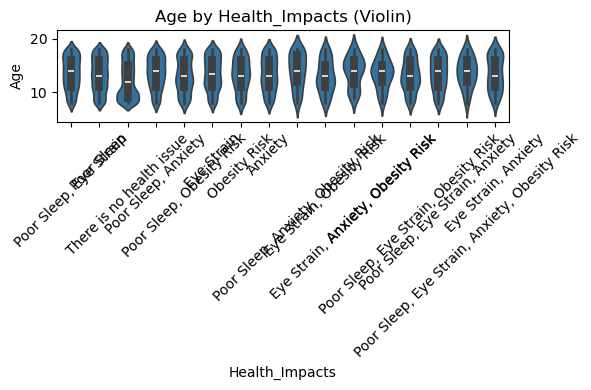

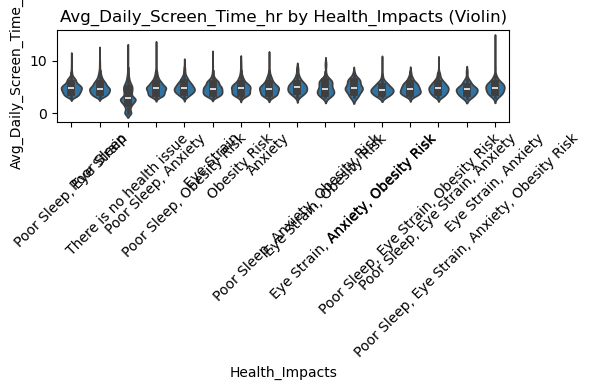

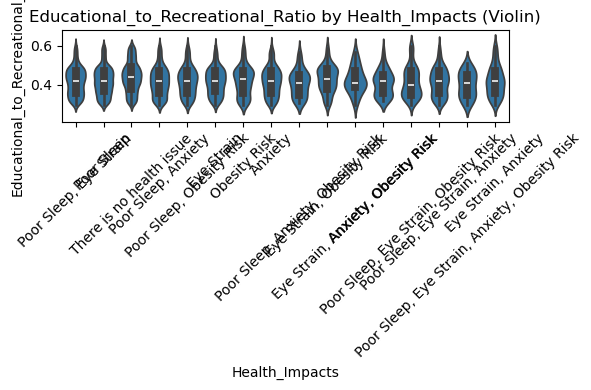

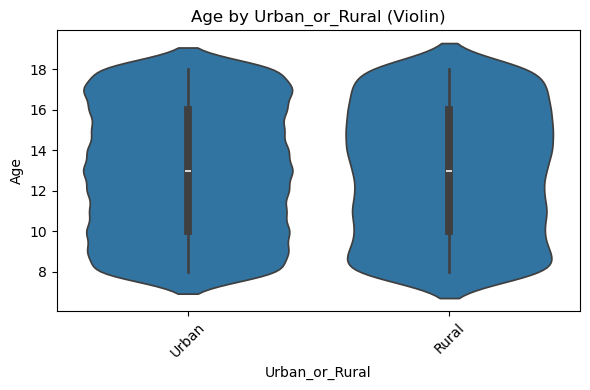

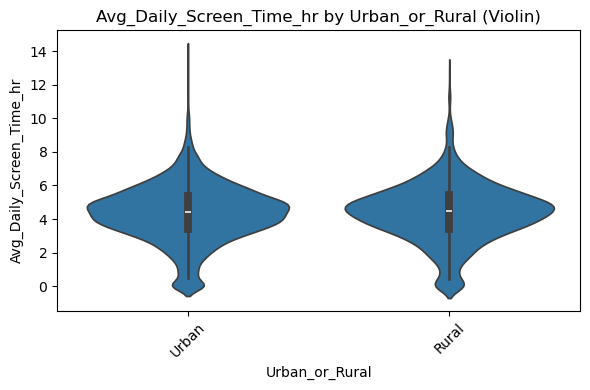

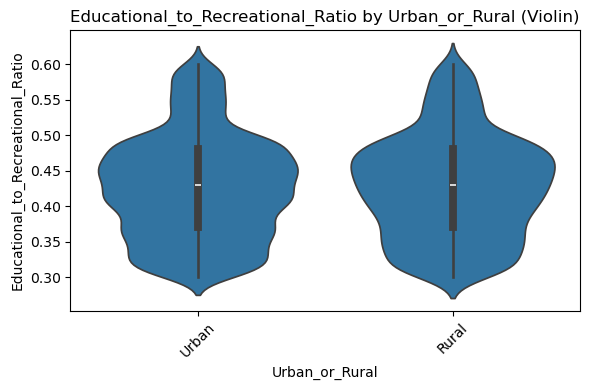

PIE & DONUT CHARTS (Excluding Health_Impacts)
CORRELATION HEATMAP


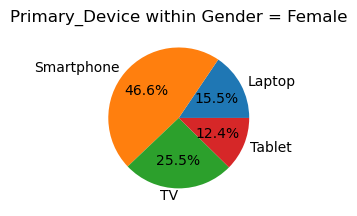

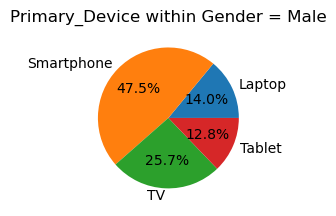

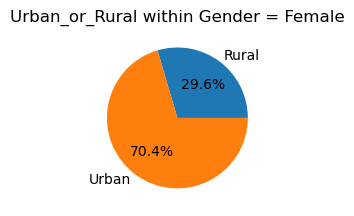

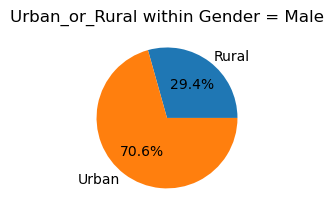

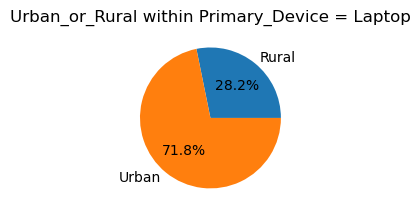

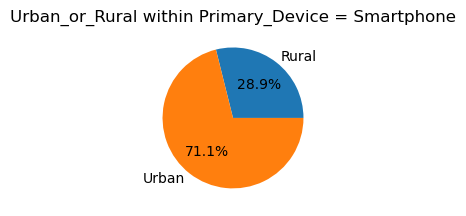

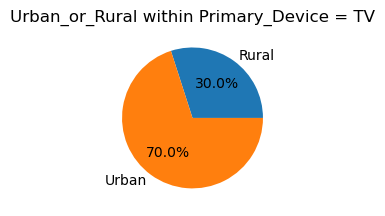

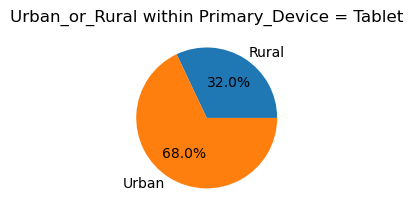

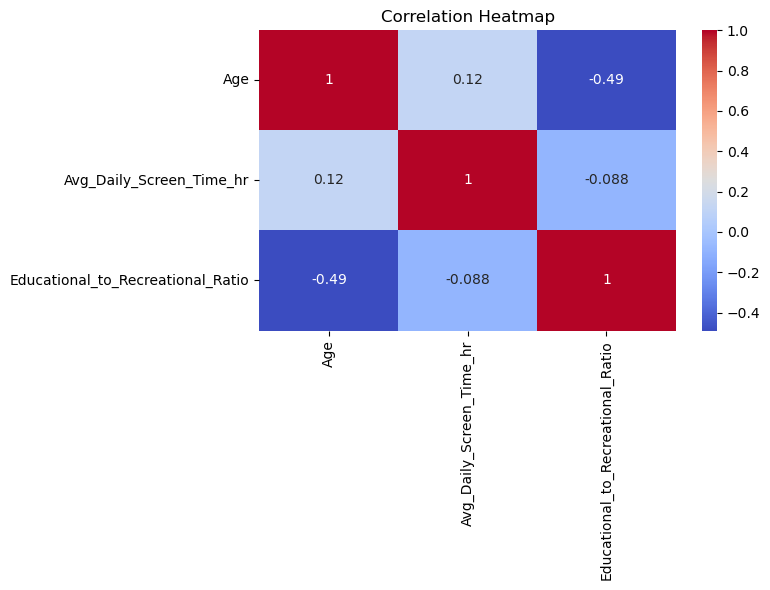

In [32]:
import itertools

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("SCATTER PLOTS (Numerical vs Numerical)")

for col1, col2 in itertools.combinations(num_cols, 2):
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col1], y=df[col2])
    plt.title(f"{col1} vs {col2}")
    plt.tight_layout()
    plt.show()

print("BOX PLOTS (Categorical vs Numerical)")

for cat in cat_cols:
    for num in num_cols:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[cat], y=df[num])
        plt.xticks(rotation=45)
        plt.title(f"{num} by {cat}")
        plt.tight_layout()
        plt.show()

print("VIOLIN PLOTS (Categorical vs Numerical)")

for cat in cat_cols:
    for num in num_cols:
        plt.figure(figsize=(6,4))
        sns.violinplot(x=df[cat], y=df[num])
        plt.xticks(rotation=45)
        plt.title(f"{num} by {cat} (Violin)")
        plt.tight_layout()
        plt.show()


print("PIE & DONUT CHARTS (Excluding Health_Impacts)")

filtered_cat_cols = [col for col in cat_cols if col != 'Health_Impacts']

for col1, col2 in itertools.combinations(filtered_cat_cols, 2):
    temp = df.groupby(col1)[col2].value_counts().unstack().fillna(0)
    
    for index in temp.index:
        plt.figure(figsize=(5,5))
        
        # PIE
        plt.subplot(1,2,1)
        temp.loc[index].plot(kind='pie', autopct='%1.1f%%')
        plt.title(f"{col2} within {col1} = {index}")
        plt.ylabel("")
        
    

print("CORRELATION HEATMAP")

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()